<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 03: Continuidad</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> XXX | <b>Fecha:</b> XX de XXX, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Este laboratorio profundiza en la noción de <b>continuidad</b>, conectando los límites con el comportamiento local de las funciones, según el <b>Capítulo 2.5 de Stewart</b>. Analizaremos cuándo una "pequeña" variación en el dominio produce una "pequeña" variación en la imagen y cómo identificar diferentes tipos de rupturas.</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Definición formal de continuidad en un punto.</li>
            <li>Clasificación de discontinuidades (Evitables, de Salto e Infinitas).</li>
            <li>Continuidad en intervalos y funciones compuestas.</li>
            <li>Teorema del Valor Intermedio (TVI).</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Implementar funciones definidas por tramos en Python.</li>
            <li>Visualizar e identificar gráficamente tipos de discontinuidad.</li>
            <li>Resolver problemas de parámetros para asegurar continuidad usando SymPy.</li>
            <li>Aplicar el TVI para localizar raíces de funciones continuas.</li>
        </ul>
    </div>
</div>

In [2]:
# importar librerias de la sesion
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

sp.init_printing()
x = sp.Symbol('x')

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")

Versión de Numpy: 1.26.4


### 1. Definición de Continuidad
Según Stewart, una función $f$ es **continua en un número $a$** si se cumplen tres condiciones:
1. $f(a)$ está definido ( $a$ está en el dominio de $f$ ).
2. $\lim_{x \to a} f(x)$ existe.
3. $\lim_{x \to a} f(x) = f(a)$.

Si $f$ no es continua en $a$, decimos que $f$ tiene una **discontinuidad** en dicho punto.

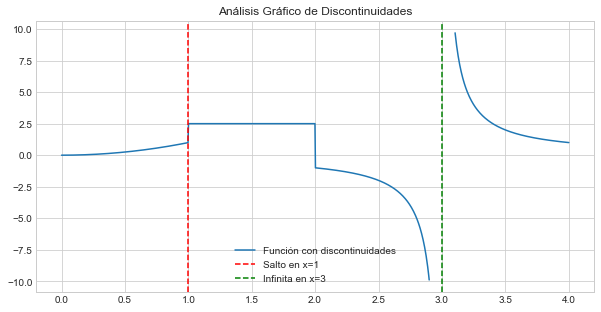

In [3]:
# Definimos una función por tramos para observar diferentes discontinuidades
def f_tramos(val_x):
    if val_x < 1:
        return val_x**2
    elif 1 <= val_x < 2:
        return 2.5  # Salto
    else:
        return 1 / (val_x - 3) # Asíntota en x=3

# Visualización
x_vals = np.linspace(0, 4, 1000)
y_vals = [f_tramos(val) for val in x_vals]
# Limpiar valores muy grandes cerca de la asíntota para mejor visualización
y_vals = [y if abs(y) < 10 else np.nan for y in y_vals]

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label="Función con discontinuidades")
plt.axvline(x=1, color='r', linestyle='--', label='Salto en x=1')
plt.axvline(x=3, color='g', linestyle='--', label='Infinita en x=3')
plt.title("Análisis Gráfico de Discontinuidades")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio Propuesto: El problema del puente
Considere la función definida por tramos:
$$f(x) = \begin{cases} cx^2 + 2x & \text{si } x < 2 \\ x^3 - cx & \text{si } x \ge 2 \end{cases}$$
Utilice **SymPy** para encontrar el valor de la constante $c$ que hace que la función sea continua en todo su dominio.

### JNB LAB: Localización de Raíces (TVI)
El **Teorema del Valor Intermedio** establece que si $f$ es continua en $[a, b]$ y $N$ es un número entre $f(a)$ y $f(b)$, existe al menos un $c \in (a, b)$ tal que $f(c) = N$.

**Misión:** Demuestre gráficamente que la función $f(x) = \cos(x) - x$ tiene una raíz en el intervalo $[0, 1]$. Utilice el método de bisección simple para encontrar una aproximación.

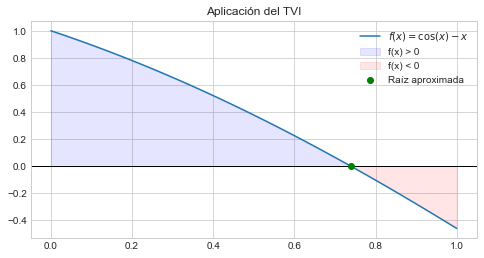

In [4]:
# Visualización del TVI
x_p = np.linspace(0, 1, 100)
y_p = np.cos(x_p) - x_p

plt.figure(figsize=(8, 4))
plt.plot(x_p, y_p, label='$f(x) = \cos(x) - x$')
plt.axhline(0, color='black', lw=1)
plt.fill_between(x_p, y_p, where=(y_p >= 0), color='blue', alpha=0.1, label='f(x) > 0')
plt.fill_between(x_p, y_p, where=(y_p <= 0), color='red', alpha=0.1, label='f(x) < 0')
plt.scatter([0.739], [0], color='green', zorder=5, label='Raíz aproximada')
plt.legend()
plt.grid(True)
plt.title("Aplicación del TVI")
plt.show()

<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > Temas/ contenidos / instrucciones del laboratorio</h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría: </h3>
    <p>  xxxxxx </p>
    <ul>
        <li> </li>
        <li> </li>
        <li> </li>
    </ul>
    <p> xxxx</b>.</p>
</div>


---
<div class="alert alert-block alert-success";  style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    
## Ticket de Salida:

<h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1: </h3>

</div>
<!-- 
<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1: </h3>
    
</div> -->

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>